In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import networkx as nx

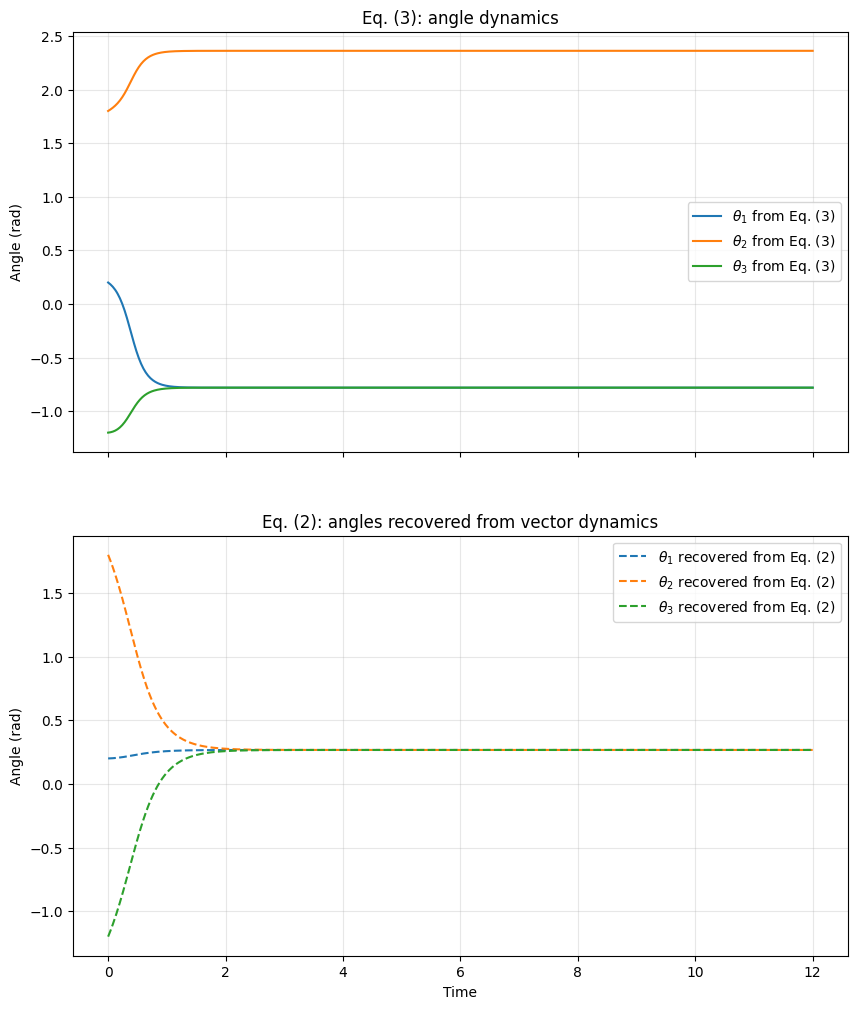

In [36]:


# ------------------------------------------------------------
# Zhang et al. (2025), Eq. (2) and Eq. (3)
#
# Eq. (2):  vdot_i = (I - v_i v_i^T) sum_{j in N_i} v_j
# Eq. (3):  thetadot_i = sum_{j in N_i} sin(theta_j - theta_i)
#
# For d = 2 and v_i = [cos(theta_i), sin(theta_i)]^T,
# ------------------------------------------------------------
G= nx.complete_graph(3)

def build_adjacency(G):
    """
    Takes a networkx graph G and outputs the adjacency
    as a numpy array 
    """
    return nx.adjacency_matrix(G).toarray()


def theta_to_v(theta):
    """
    Convert angles theta_i to stacked vector states:
        [v1x, v1y, v2x, v2y, v3x, v3y]
    """
    n = len(theta)
    v = np.zeros(2 * n)
    for i in range(n):
        v[2 * i: 2 * i + 2] = [np.cos(theta[i]), np.sin(theta[i])]
    return v


def v_to_theta(v):
    """
    Recover angles from stacked vector state.
    """
    n = len(v) // 2
    theta = np.zeros(n)
    for i in range(n):
        x, y = v[2 * i: 2 * i + 2]
        theta[i] = np.arctan2(y, x)
    return theta


def chebyshev_U(n, x):
    if n == 0:
        return 1.0
    elif n == 1:
        return 2 * x
    elif n == 2:
        return 4 * x**2 - 1
    elif n == 3:
        return 8 * x**3 - 4 * x
    else:
        raise NotImplementedError("Extend for higher k")
    
    

def rhs_eq2(t, v, A, k=1):
    n = A.shape[0]
    I2 = np.eye(2)
    dv = np.zeros_like(v)

    for i in range(n):
        vi = v[2*i:2*i+2]
        neighbor_sum = np.zeros(2)

        for j in range(n):
            if A[i, j] != 0:
                vj = v[2*j:2*j+2]

                x = np.dot(vi, vj)  # inner product
                weight = chebyshev_U(k-1, x)

                neighbor_sum += A[i, j] * weight * vj

        projection = I2 - np.outer(vi, vi)
        dvi = projection @ neighbor_sum
        dv[2*i:2*i+2] = dvi

    return dv



def rhs_eq3(t, theta, A, k):
    n = A.shape[0]
    dtheta = np.zeros_like(theta)

    for i in range(n):
        for j in range(n):
            if A[i, j] != 0:
                dtheta[i] += A[i, j] * np.sin(k * (theta[j] - theta[i]))

    return dtheta


def wrap_angle(angle):
    """
    Wrap to [-pi, pi).
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi


def compare_models(G, k):
    A = build_adjacency(G)
    n = A.shape[0]

    # Initial angles for the 3 nodes
    theta0 = np.array([0.2, 1.8, -1.2])

    # Convert to vector initial condition for Eq. (2)
    v0 = theta_to_v(theta0)

    # Time span
    t_span = (0.0, 12.0)
    t_eval = np.linspace(t_span[0], t_span[1], 600)

    # Solve Eq. (2)
    sol_v = solve_ivp(
        fun=lambda t, y: rhs_eq2(t, y, A),
        t_span=t_span,
        y0=v0,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-9
    )

    # Solve Eq. (3)
    sol_theta = solve_ivp(
        fun=lambda t, y: rhs_eq3(t, y, A, k),
        t_span=t_span,
        y0=theta0,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-9
    )

    # Recover angles from Eq. (2) trajectory
    theta_from_v = np.zeros((n, len(t_eval)))
    norms = np.zeros((n, len(t_eval)))

    for k in range(len(t_eval)):
        vk = sol_v.y[:, k]
        theta_from_v[:, k] = v_to_theta(vk)
        for i in range(n):
            vi = vk[2 * i: 2 * i + 2]
            norms[i, k] = np.linalg.norm(vi)

    # Compute angle differences between the two models
    angle_error = wrap_angle(theta_from_v - sol_theta.y)

    # Print summary
    #print("Maximum absolute wrapped angle error per node:")
    #for i in range(n):
    #    print(f"  node {i+1}: {np.max(np.abs(angle_error[i, :])):.3e} rad")

    #print("\nMaximum deviation from unit norm in Eq. (2):")
    #for i in range(n):
    #    print(f"  node {i+1}: {np.max(np.abs(norms[i, :] - 1.0)):.3e}")

    # ------------------------------------------------------------
    # Plot results
    # ------------------------------------------------------------
    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

    # Angles from Eq. (3)
    for i in range(n):
        axes[0].plot(t_eval, sol_theta.y[i], label=f"$\\theta_{i+1}$ from Eq. (3)")
    axes[0].set_ylabel("Angle (rad)")
    axes[0].set_title("Eq. (3): angle dynamics")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Angles recovered from Eq. (2)
    for i in range(n):
        axes[1].plot(t_eval, theta_from_v[i], "--", label=f"$\\theta_{i+1}$ recovered from Eq. (2)")
    axes[1].set_ylabel("Angle (rad)")
    axes[1].set_title("Eq. (2): angles recovered from vector dynamics")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel("Time")

    # Error between the two
   # for i in range(n):
   #     axes[2].plot(t_eval, angle_error[i], label=f"node {i+1}")
   # axes[2].set_xlabel("Time")
   # axes[2].set_ylabel("Wrapped error (rad)")
   # axes[2].set_title("Difference between Eq. (2) and Eq. (3)")
   # axes[2].legend()
   # axes[2].grid(True, alpha=0.3)

   # plt.tight_layout()
   # plt.show()

    # ------------------------------------------------------------
    # phase portrait on the unit circle
    # ------------------------------------------------------------
    #plt.figure(figsize=(6, 6))
    #circle = np.linspace(0, 2 * np.pi, 400)
    #plt.plot(np.cos(circle), np.sin(circle), "k-", alpha=0.4)

    #colors = ["tab:blue", "tab:orange", "tab:green"]
    #for i in range(n):
    #    xi = sol_v.y[2 * i, :]
    #    yi = sol_v.y[2 * i + 1, :]
    #   plt.plot(xi, yi, color=colors[i], label=f"node {i+1}")
    #   plt.scatter([xi[0]], [yi[0]], color=colors[i], marker="o", s=50)
    #   plt.scatter([xi[-1]], [yi[-1]], color=colors[i], marker="x", s=70)

    #plt.axis("equal")
    #plt.xlabel("x")
    #plt.ylabel("y")
    #plt.title("Eq. (2): opinion trajectories on the unit circle")
    #plt.legend()
    #plt.grid(True, alpha=0.3)
    #plt.show()


if __name__ == "__main__":
    compare_models(G, k)